<a href="https://colab.research.google.com/github/lcn781/M9/blob/main/Mod9Tarefa2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Livro para consulta:
- https://jakevdp.github.io/PythonDataScienceHandbook/03.08-aggregation-and-grouping.html
- https://jakevdp.github.io/PythonDataScienceHandbook/03.09-pivot-tables.html
    

# 1. Importando bibliotecas <a name="import"></a>

<div style="text-align: right"
     
[Voltar ao índice](#Contents)

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

# 2. Carregando o dataframe SINASC <a name="read"></a>
<div style="text-align: right"
     
[Voltar ao índice](#Contents)

In [ ]:
sinasc_raw = pd.read_csv('SINASC_RO_2019.csv')
sinasc_raw.shape

(27028, 69)

In [ ]:
df_x = sinasc_raw[sinasc_raw['IDADEMAE'] <= 16].copy()
df_x.shape

(1186, 69)

# Tarefa 2

### 1. Crie 2 faixas de Latitude do município (munResLat) sendo uma acima e outra abaixo de -10.5 e aplique o groupby usando essas faixas como chave e realize operações de soma, media, minimo, maximo, mediana, desvio padrao, variancia pra pelo menos 2 variáveis numéricas ainda não utilizadas

In [ ]:
df_1 = sinasc_raw[['QTDGESTANT', 'QTDPARTNOR', 'QTDPARTCES', 'QTDFILVIVO', 'QTDFILMORT', 'munResLat']]

In [ ]:
df_1 = df_1.dropna(subset=['munResLat'])
corte = -10.5
bins = [-float('inf'), corte, float('inf')]
labels = [f'⬇️{corte}', f'⬆️{corte}']
df_1['faixa_latitude'] = pd.cut(df_1['munResLat'], bins=bins, labels=labels)
print(f"Ponto de corte: {corte}")

Ponto de corte: -10.5


In [ ]:
df_1.shape

(27027, 7)

In [ ]:
distribuicao = df_1['faixa_latitude'].value_counts()
print(distribuicao)

faixa_latitude
⬆️-10.5    14034
⬇️-10.5    12993
Name: count, dtype: int64


In [ ]:
resultado = df_1.drop(columns='munResLat').groupby('faixa_latitude', observed=True).agg(['sum', 'mean', 'min', 'max', 'median', 'std']).round(2)
print(resultado)

               QTDGESTANT                               QTDPARTNOR             \
                      sum  mean  min   max median   std        sum  mean  min   
faixa_latitude                                                                  
⬇️-10.5           15301.0  1.19  0.0  15.0    1.0  1.30     5800.0  0.45  0.0   
⬆️-10.5           17615.0  1.36  0.0  52.0    1.0  1.49     8771.0  0.71  0.0   

                      ... QTDFILVIVO                    QTDFILMORT             \
                 max  ...        min   max median   std        sum  mean  min   
faixa_latitude        ...                                                       
⬇️-10.5         41.0  ...        0.0  30.0    1.0  1.14     3105.0  0.24  0.0   
⬆️-10.5         40.0  ...        0.0  12.0    1.0  1.20     3538.0  0.29  0.0   

                                   
                 max median   std  
faixa_latitude                     
⬇️-10.5         28.0    0.0  0.60  
⬆️-10.5          9.0    0.0  0.63  

[2 rows

In [ ]:
pivot = resultado.pivot_table(index='faixa_latitude', observed=False, values=['QTDPARTNOR', 'QTDPARTCES'], aggfunc='mean')
print(pivot)

               QTDPARTCES                                 QTDPARTNOR        \
                      max  mean median  min   std     sum        max  mean   
faixa_latitude                                                               
⬇️-10.5              12.0  0.55    0.0  0.0  0.75  7095.0       41.0  0.45   
⬆️-10.5              12.0  0.49    0.0  0.0  0.74  6041.0       40.0  0.71   

                                          
               median  min   std     sum  
faixa_latitude                            
⬇️-10.5           0.0  0.0  1.12  5800.0  
⬆️-10.5           0.0  0.0  1.28  8771.0  


In [ ]:
pivot_stacked = resultado.stack(future_stack=True).round(2)
print(pivot_stacked)

                       QTDGESTANT  QTDPARTNOR  QTDPARTCES  QTDFILVIVO  \
faixa_latitude                                                          
⬇️-10.5        sum       15301.00     5800.00     7095.00    12600.00   
               mean          1.19        0.45        0.55        0.98   
               min           0.00        0.00        0.00        0.00   
               max          15.00       41.00       12.00       30.00   
               median        1.00        0.00        0.00        1.00   
               std           1.30        1.12        0.75        1.14   
⬆️-10.5        sum       17615.00     8771.00     6041.00    14226.00   
               mean          1.36        0.71        0.49        1.13   
               min           0.00        0.00        0.00        0.00   
               max          52.00       40.00       12.00       12.00   
               median        1.00        0.00        0.00        1.00   
               std           1.49        1.28      

### 2. Crie 2 faixas da área dos municípios (munResArea) sendo uma acima e outra abaixo de 3000 e aplique o groupby usando essas faixas como chave e realize operações de soma, media, minimo, maximo, mediana, desvio padrao, variancia pra pelo menos 2 variáveis numéricas ainda não utilizadas


In [ ]:
df_2 = sinasc_raw[['QTDGESTANT', 'QTDPARTNOR', 'QTDPARTCES', 'QTDFILVIVO', 'QTDFILMORT', 'munResArea']].dropna(subset=['munResArea'])
corte_2 = 3000
bins_2 = [-float('inf'), corte_2, float('inf')]
labels_2 = [f'Menores', f'Maiores']
df_2['Área'] = pd.cut(df_2['munResArea'], bins=bins_2, labels=labels_2)
df_2.shape

(27027, 7)

In [ ]:
resultado_2 = df_2.drop(columns=['munResArea']).groupby('Área', observed=False).agg(['sum', 'mean', 'min', 'max', 'median', 'std']).round(2)
print(resultado_2)


        QTDGESTANT                               QTDPARTNOR                   \
               sum  mean  min   max median   std        sum  mean  min   max   
Área                                                                           
Menores     5870.0  1.13  0.0   9.0    1.0  1.21     1912.0  0.37  0.0  10.0   
Maiores    27046.0  1.31  0.0  52.0    1.0  1.45    12659.0  0.63  0.0  41.0   

         ... QTDFILVIVO                    QTDFILMORT                          \
         ...        min   max median   std        sum  mean  min   max median   
Área     ...                                                                    
Menores  ...        0.0  30.0    1.0  1.08     1260.0  0.24  0.0   4.0    0.0   
Maiores  ...        0.0  14.0    1.0  1.19     5383.0  0.27  0.0  28.0    0.0   

               
          std  
Área           
Menores  0.55  
Maiores  0.63  

[2 rows x 30 columns]


In [ ]:
pivot_stacked_2 = resultado_2.stack(future_stack=True).round(2)
print(pivot_stacked_2)


                QTDGESTANT  QTDPARTNOR  QTDPARTCES  QTDFILVIVO  QTDFILMORT
Área                                                                      
Menores sum        5870.00     1912.00     2952.00     4773.00     1260.00
        mean          1.13        0.37        0.57        0.92        0.24
        min           0.00        0.00        0.00        0.00        0.00
        max           9.00       10.00        5.00       30.00        4.00
        median        1.00        0.00        0.00        1.00        0.00
        std           1.21        0.86        0.75        1.08        0.55
Maiores sum       27046.00    12659.00    10184.00    22053.00     5383.00
        mean          1.31        0.63        0.51        1.09        0.27
        min           0.00        0.00        0.00        0.00        0.00
        max          52.00       41.00       12.00       14.00       28.00
        median        1.00        0.00        0.00        1.00        0.00
        std           1.4

### 3. Determine faixas na variável munResAlt e aplique o groupby usando essas faixas como chave e realize operações de soma, media, minimo, maximo, mediana, desvio padrao, variancia pra pelo menos 2 variáveis numéricas ainda não utilizadas

In [ ]:
sinasc_raw['munResAlt'].describe().round(2)

,munResAlt
count,27027.00
mean,179.11
std,123.14
min,85.00
25%,87.00
50%,153.00
75%,191.00
max,595.00


In [ ]:
df_3 = sinasc_raw[['QTDGESTANT', 'QTDPARTNOR', 'QTDPARTCES', 'QTDFILVIVO', 'QTDFILMORT', 'munResAlt']].dropna(subset=['munResAlt'])
bins_altitude = [-float('inf'), 200, 500, float('inf')]
labels_altitude = ['Baixa', 'Média', 'Alta']
df_3['faixa_altitude'] = pd.cut(df_3['munResAlt'], bins=bins_altitude, labels=labels_altitude, right=False)
resultado_3 = df_3.drop(columns=['munResAlt']).groupby('faixa_altitude', observed=False).agg(['sum', 'mean', 'min', 'max', 'median', 'std', 'var']).round(2)
print(resultado_3)


               QTDGESTANT                                     QTDPARTNOR  \
                      sum  mean  min   max median   std   var        sum   
faixa_altitude                                                             
Baixa             25913.0  1.32  0.0  52.0    1.0  1.45  2.12    12325.0   
Média              5190.0  1.14  0.0  12.0    1.0  1.22  1.49     1724.0   
Alta               1813.0  1.14  0.0   9.0    1.0  1.21  1.47      522.0   

                           ... QTDFILVIVO             QTDFILMORT             \
                mean  min  ...     median   std   var        sum  mean  min   
faixa_altitude             ...                                                
Baixa           0.65  0.0  ...        1.0  1.20  1.43     5169.0  0.27  0.0   
Média           0.38  0.0  ...        1.0  1.11  1.22     1076.0  0.24  0.0   
Alta            0.33  0.0  ...        1.0  1.02  1.04      398.0  0.25  0.0   

                                         
                 max media

In [ ]:
pivot_stacked_3 = resultado_3.stack(future_stack=True).round(2)
print(pivot_stacked_3)


                       QTDGESTANT  QTDPARTNOR  QTDPARTCES  QTDFILVIVO  \
faixa_altitude                                                          
Baixa          sum       25913.00    12325.00     9406.00    21006.00   
               mean          1.32        0.65        0.49        1.09   
               min           0.00        0.00        0.00        0.00   
               max          52.00       40.00       12.00       14.00   
               median        1.00        0.00        0.00        1.00   
               std           1.45        1.23        0.74        1.20   
               var           2.12        1.50        0.55        1.43   
Média          sum        5190.00     1724.00     2792.00     4366.00   
               mean          1.14        0.38        0.62        0.96   
               min           0.00        0.00        0.00        0.00   
               max          12.00       41.00        5.00       30.00   
               median        1.00        0.00      

### 4. Plote no mesmo grafico ao longo do tempo a idade media das mulheres de cada regiao imediatas de rondonia


In [ ]:
imediatas = {
    "Candeias do Jamari": "Porto Velho",
    "Guajará-Mirim": "Porto Velho",
    "Itapuã do Oeste": "Porto Velho",
    "Nova Mamoré": "Porto Velho",
    "Porto Velho": "Porto Velho",
    "Ariquemes": "Ariquemes",
    "Alto Paraíso": "Ariquemes",
    "Buritis": "Ariquemes",
    "Cacaulândia": "Ariquemes",
    "Campo Novo de Rondônia": "Ariquemes",
    "Cujubim": "Ariquemes",
    "Monte Negro": "Ariquemes",
    "Rio Crespo": "Ariquemes",
    "Jaru": "Jaru",
    "Governador Jorge Teixeira": "Jaru",
    "Machadinho D'Oeste": "Jaru",
    "Theobroma": "Jaru",
    "Vale do Anari": "Jaru",
    "Alvorada D'Oeste": "Ji-Paraná",
    "Costa Marques": "Ji-Paraná",
    "Ji-Paraná": "Ji-Paraná",
    "Mirante da Serra": "Ji-Paraná",
    "Nova União": "Ji-Paraná",
    "Ouro Preto do Oeste": "Ji-Paraná",
    "Presidente Médici": "Ji-Paraná",
    "São Francisco do Guaporé": "Ji-Paraná",
    "São Miguel do Guaporé": "Ji-Paraná",
    "Seringueiras": "Ji-Paraná",
    "Teixeirópolis": "Ji-Paraná",
    "Urupá": "Ji-Paraná",
    "Vale do Paraíso": "Ji-Paraná",
    "Cacoal": "Cacoal",
    "Alta Floresta D'Oeste": "Cacoal",
    "Alto Alegre dos Parecis": "Cacoal",
    "Castanheiras": "Cacoal",
    "Espigão D'Oeste": "Cacoal",
    "Ministro Andreazza": "Cacoal",
    "Nova Brasilândia D'Oeste": "Cacoal",
    "Novo Horizonte do Oeste": "Cacoal",
    "Parecis": "Cacoal",
    "Pimenta Bueno": "Cacoal",
    "Primavera de Rondônia": "Cacoal",
    "Rolim de Moura": "Cacoal",
    "Santa Luzia D'Oeste": "Cacoal",
    "São Felipe D'Oeste": "Cacoal",
    "Vilhena": "Vilhena",
    "Cabixi": "Vilhena",
    "Cerejeiras": "Vilhena",
    "Chupinguaia": "Vilhena",
    "Colorado do Oeste": "Vilhena",
    "Corumbiara": "Vilhena",
    "Pimenteiras do Oeste": "Vilhena"
}

In [ ]:
df_4 = sinasc_raw.copy()
df_4['regiao'] = df_4['munResNome'].map(imediatas)
df_4['regiao'].value_counts()


,count
regiao,
Porto Velho,10096
Ji-Paraná,4962
Cacoal,4603
Ariquemes,3233
Vilhena,2450
Jaru,1683


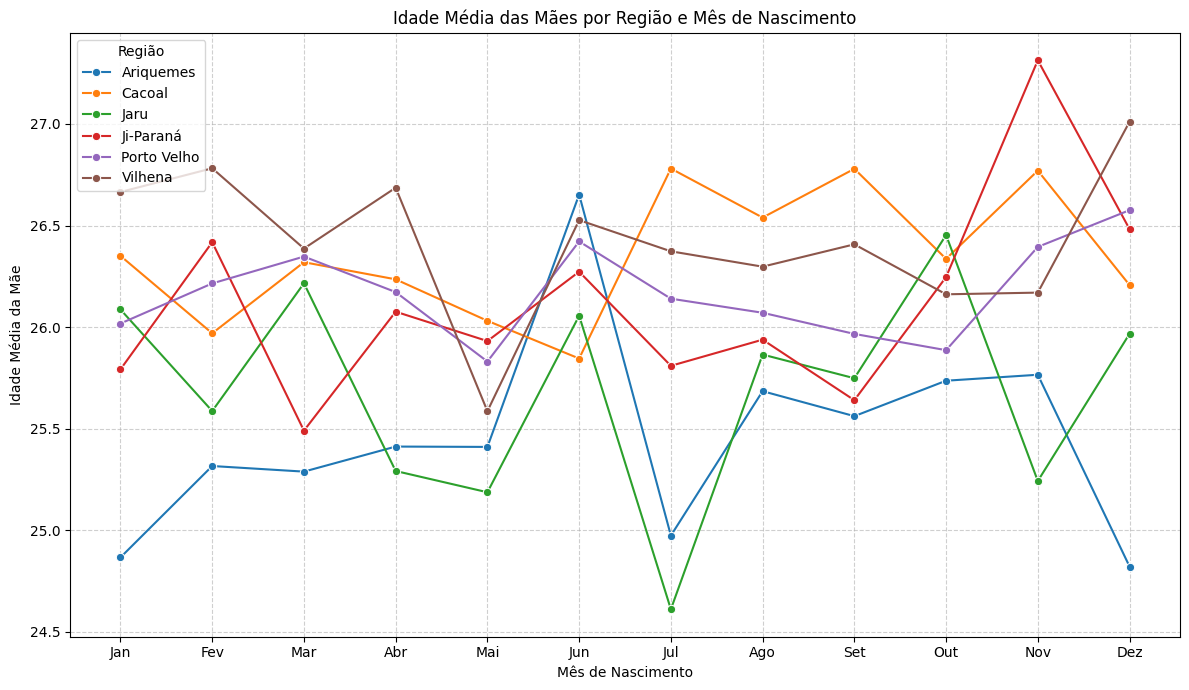

In [ ]:
# Convert 'DTNASC' to datetime objects and extract the month
df_4['DTNASC'] = pd.to_datetime(df_4['DTNASC'], errors='coerce')
df_4['MesNascimento'] = df_4['DTNASC'].dt.month

# Drop rows where 'IDADEMAE' or 'MesNascimento' are missing
df_plot = df_4.dropna(subset=['IDADEMAE', 'MesNascimento', 'regiao'])

# Calculate the mean age of mothers for each region and month
idade_media_regiao = df_plot.groupby(['regiao', 'MesNascimento'])['IDADEMAE'].mean().reset_index()

# Plotting the data
plt.figure(figsize=(12, 7))
sns.lineplot(data=idade_media_regiao, x='MesNascimento', y='IDADEMAE', hue='regiao', marker='o')

plt.title('Idade Média das Mães por Região e Mês de Nascimento')
plt.xlabel('Mês de Nascimento')
plt.ylabel('Idade Média da Mãe')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Região')
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])
plt.tight_layout()
plt.show()


### 5. Utilize a tabela do link abaixo e crie faixas utilizando o mapping e gere agrupamentos utilizando essas faixas como chave


### 5.1 IDH
A - https://pt.wikipedia.org/wiki/Lista_de_munic%C3%ADpios_de_Rond%C3%B4nia_por_IDH-M


In [ ]:
idh = pd.read_csv('/content/IDH RONDONIA.csv', sep=';')
idh = idh.drop(columns=['Unnamed: 0'])
idh.columns = ['municipio', 'IDH']
idh = idh.drop(0)
idh.shape

(52, 2)

In [ ]:
df_5 = sinasc_raw.copy()
# Convert idh DataFrame into a Series for mapping
idh_mapping = idh.set_index('municipio')['IDH']
df_5['IDH'] = df_5['munResNome'].map(idh_mapping)
df_5.head()


,ORIGEM,CODESTAB,CODMUNNASC,LOCNASC,IDADEMAE,ESTCIVMAE,ESCMAE,CODOCUPMAE,QTDFILVIVO,QTDFILMORT,...,CONTADOR,munResStatus,munResTipo,munResNome,munResUf,munResLat,munResLon,munResAlt,munResArea,IDH
0,1,2679477.0,110001,1,19,5.0,8 a 11 anos,NaN,0.0,0.0,...,1,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025,NaN
1,1,2679477.0,110001,1,29,2.0,8 a 11 anos,999992.0,1.0,0.0,...,2,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025,NaN
2,1,2679477.0,110001,1,37,9.0,8 a 11 anos,513205.0,2.0,0.0,...,3,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025,NaN
3,1,2516500.0,110001,1,30,5.0,12 anos ou mais,231205.0,0.0,0.0,...,4,ATIVO,MUNIC,Alto Alegre dos Parecis,Rondônia,-12.13178,-61.85308,397.0,3958.273,592
4,1,2516500.0,110001,1,30,2.0,8 a 11 anos,999992.0,1.0,0.0,...,5,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025,NaN


In [ ]:
# Limpar os nomes dos municípios no DataFrame 'idh'
idh['municipio'] = idh['municipio'].str.lower().str.strip().str.replace('d’oeste', 'd\'oeste').str.replace(' ', '-').str.replace('do-oeste', 'd\'oeste').str.replace('de-rondonia', 'de-rondônia')

# Limpar os nomes dos municípios no DataFrame 'df_5'
df_5['munResNome_limpo'] = df_5['munResNome'].str.lower().str.strip().str.replace('d’oeste', 'd\'oeste').str.replace(' ', '-').str.replace('do-oeste', 'd\'oeste').str.replace('de-rondonia', 'de-rondônia')

# Criar um novo mapeamento com os nomes limpos
idh_mapping_cleaned = idh.set_index('municipio')['IDH']
df_5['IDH_limpo'] = df_5['munResNome_limpo'].map(idh_mapping_cleaned)

# Verificar quantos valores ainda são NaN após a limpeza
nan_count = df_5['IDH_limpo'].isnull().sum()
total_count = len(df_5)
print(f"Total de registros: {total_count}")
print(f"Registros com 'IDH_limpo' como NaN: {nan_count}")
print(f"Porcentagem de NaN: {nan_count / total_count * 100:.2f}%")
display(df_5[['munResNome', 'munResNome_limpo', 'IDH_limpo']].head())

Total de registros: 27028
Registros com 'IDH_limpo' como NaN: 1
Porcentagem de NaN: 0.00%


,munResNome,munResNome_limpo,IDH_limpo
0,Alta Floresta D'Oeste,alta-floresta-d'oeste,641
1,Alta Floresta D'Oeste,alta-floresta-d'oeste,641
2,Alta Floresta D'Oeste,alta-floresta-d'oeste,641
3,Alto Alegre dos Parecis,alto-alegre-dos-parecis,592
4,Alta Floresta D'Oeste,alta-floresta-d'oeste,641


In [ ]:
unmapped_mun = df_5[df_5['IDH_limpo'].isnull()]['munResNome_limpo'].unique()
print("Municípios não mapeados:")
for mun in unmapped_mun:
    print(mun)

print("\nVerifique se esses nomes estão presentes no seu arquivo 'IDH RONDONIA.csv' ou se possuem variações diferentes.")

Municípios não mapeados:
município-ignorado---ro

Verifique se esses nomes estão presentes no seu arquivo 'IDH RONDONIA.csv' ou se possuem variações diferentes.


In [ ]:
# Converter a coluna 'IDH_limpo' para numérica, forçando erros para NaN
df_5['IDH_limpo'] = pd.to_numeric(df_5['IDH_limpo'], errors='coerce')

# Remover linhas onde 'IDH_limpo' ou as variáveis numéricas estão nulas
df_5_grouped = df_5.dropna(subset=['IDH_limpo', 'QTDGESTANT', 'QTDPARTNOR', 'QTDPARTCES', 'QTDFILVIVO', 'QTDFILMORT']).copy()

# Definir as faixas para o IDH, excluindo 'Muito Baixo' e 'Muito Alto'
bins_idh = [0.5, 0.6, 0.7, 0.8]
labels_idh = ['Baixo', 'Médio', 'Alto']

# Criar a nova coluna 'faixa_IDH'
df_5_grouped['faixa_IDH'] = pd.cut(df_5_grouped['IDH_limpo'] / 1000, bins=bins_idh, labels=labels_idh, right=False)

# Realizar o groupby usando as faixas de IDH e aplicar as operações agregadas
resultado_idh = df_5_grouped.groupby('faixa_IDH', observed=False)[['QTDGESTANT', 'QTDPARTNOR', 'QTDPARTCES', 'QTDFILVIVO', 'QTDFILMORT']].agg(['sum', 'mean', 'min', 'max', 'median', 'std', 'var']).round(2)

print(resultado_idh)

# Exibir a distribuição das faixas de IDH em porcentagem
print("\nDistribuição das faixas de IDH (porcentagem):")
print(df_5_grouped['faixa_IDH'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

          QTDGESTANT                                     QTDPARTNOR        \
                 sum  mean  min   max median   std   var        sum  mean   
faixa_IDH                                                                   
Baixo         2037.0  1.24  0.0  11.0    1.0  1.38  1.90     1009.0  0.61   
Médio         9777.0  1.27  0.0  15.0    1.0  1.42  2.00     4198.0  0.55   
Alto         19112.0  1.25  0.0  13.0    1.0  1.33  1.76     8449.0  0.55   

                ... QTDFILVIVO             QTDFILMORT                          \
           min  ...     median   std   var        sum  mean  min   max median   
faixa_IDH       ...                                                             
Baixo      0.0  ...        1.0  1.18  1.40      370.0  0.22  0.0   9.0    0.0   
Médio      0.0  ...        1.0  1.20  1.44     1920.0  0.25  0.0   7.0    0.0   
Alto       0.0  ...        1.0  1.12  1.26     4013.0  0.26  0.0  28.0    0.0   

                       
            std   var  
fa

In [ ]:
pivot_stacked_idh = resultado_idh.stack(future_stack=True).round(2)
print(pivot_stacked_idh)

                  QTDGESTANT  QTDPARTNOR  QTDPARTCES  QTDFILVIVO  QTDFILMORT
faixa_IDH                                                                   
Baixo     sum        2037.00     1009.00      775.00     1738.00      370.00
          mean          1.24        0.61        0.47        1.05        0.22
          min           0.00        0.00        0.00        0.00        0.00
          max          11.00       10.00        3.00       10.00        9.00
          median        1.00        0.00        0.00        1.00        0.00
          std           1.38        1.15        0.70        1.18        0.58
          var           1.90        1.33        0.49        1.40        0.34
Médio     sum        9777.00     4198.00     4232.00     8198.00     1920.00
          mean          1.27        0.55        0.55        1.06        0.25
          min           0.00        0.00        0.00        0.00        0.00
          max          15.00       40.00        5.00       12.00        7.00

### 5.2 IFDM
B - https://pt.wikipedia.org/wiki/Lista_de_munic%C3%ADpios_de_Rond%C3%B4nia_por_IFDM


In [ ]:
df_5_2 = sinasc_raw.copy()
df_5_2.shape

(27028, 69)

In [ ]:
ifdm = pd.read_csv('/content/IFDM RONDONIA.csv', sep=';')
ifdm = ifdm.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])
ifdm.columns = ['municipio', 'IFDM']
ifdm.shape

(52, 2)

In [ ]:
# Limpar os nomes dos municípios no DataFrame 'ifdm'
ifdm['municipio'] = ifdm['municipio'].str.lower().str.strip().str.replace('d’oeste', 'd\'oeste').str.replace(' ', '-').str.replace('do-oeste', 'd\'oeste').str.replace('de-rondonia', 'de-rondônia')

# Limpar os nomes dos municípios no DataFrame 'df_5_2'
df_5_2['munResNome_limpo'] = df_5_2['munResNome'].str.lower().str.strip().str.replace('d’oeste', 'd\'oeste').str.replace(' ', '-').str.replace('do-oeste', 'd\'oeste').str.replace('de-rondonia', 'de-rondônia')

# Criar um novo mapeamento com os nomes limpos
ifdm_mapping_cleaned = ifdm.set_index('municipio')['IFDM']
df_5_2['IFDM_limpo'] = df_5_2['munResNome_limpo'].map(ifdm_mapping_cleaned)

# Verificar quantos valores ainda são NaN após a limpeza
nan_count = df_5_2['IFDM_limpo'].isnull().sum()
total_count = len(df_5_2)
print(f"Total de registros: {total_count}")
print(f"Registros com 'IFDM_limpo' como NaN: {nan_count}")
print(f"Porcentagem de NaN: {nan_count / total_count * 100:.2f}%")
display(df_5_2[['munResNome', 'munResNome_limpo', 'IFDM_limpo']].head())

Total de registros: 27028
Registros com 'IFDM_limpo' como NaN: 1
Porcentagem de NaN: 0.00%


,munResNome,munResNome_limpo,IFDM_limpo
0,Alta Floresta D'Oeste,alta-floresta-d'oeste,0.6337
1,Alta Floresta D'Oeste,alta-floresta-d'oeste,0.6337
2,Alta Floresta D'Oeste,alta-floresta-d'oeste,0.6337
3,Alto Alegre dos Parecis,alto-alegre-dos-parecis,0.5046
4,Alta Floresta D'Oeste,alta-floresta-d'oeste,0.6337


In [ ]:
bins_ifdm = [-float('inf'), 0.6, float('inf')]
labels_ifdm = ['Moderado', 'Regular']
df_5_2['faixa_IFDM'] = pd.cut(df_5_2['IFDM_limpo'], bins=bins_ifdm, labels=labels_ifdm, right=False)
resultado_ifdm = df_5_2.groupby('faixa_IFDM', observed=False)[['QTDGESTANT', 'QTDPARTNOR', 'QTDPARTCES', 'QTDFILVIVO', 'QTDFILMORT']].agg(['sum', 'mean', 'min', 'max', 'median', 'std', 'var']).round(2)
print(resultado_ifdm)

print("\nDistribuição das faixas de IFDM (porcentagem):")
print(df_5_2['faixa_IFDM'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')


           QTDGESTANT                                     QTDPARTNOR        \
                  sum  mean  min   max median   std   var        sum  mean   
faixa_IFDM                                                                   
Moderado       6769.0  1.35  0.0  52.0    1.0  1.67  2.80     3374.0  0.69   
Regular       26147.0  1.26  0.0  14.0    1.0  1.33  1.77    11197.0  0.55   

                 ... QTDFILVIVO             QTDFILMORT                   \
            min  ...     median   std   var        sum  mean  min   max   
faixa_IFDM       ...                                                      
Moderado    0.0  ...        1.0  1.29  1.67     1221.0  0.25  0.0   9.0   
Regular     0.0  ...        1.0  1.14  1.29     5422.0  0.27  0.0  28.0   

                               
           median   std   var  
faixa_IFDM                     
Moderado      0.0  0.59  0.35  
Regular       0.0  0.62  0.38  

[2 rows x 35 columns]

Distribuição das faixas de IFDM (porcentagem):
fa

In [ ]:
resultado_ifdm.stack(future_stack=True).round(2)

QTDGESTANT  QTDPARTNOR  QTDPARTCES  QTDFILVIVO  QTDFILMORT
faixa_IFDM                                                                   
Moderado   sum        6769.00     3374.00     2613.00     5752.00     1221.00
           mean          1.35        0.69        0.53        1.16        0.25
           min           0.00        0.00        0.00        0.00        0.00
           max          52.00       41.00        4.00       14.00        9.00
           median        1.00        0.00        0.00        1.00        0.00
           std           1.67        1.51        0.72        1.29        0.59
           var           2.80        2.27        0.53        1.67        0.35
Regular    sum       26147.00    11197.00    10523.00    21074.00     5422.00
           mean          1.26        0.55        0.52        1.03        0.27
           min           0.00        0.00        0.00        0.00        0.00
           max          14.00       40.00       12.00       30.00       28.00
           median        1.00        0.00        0.00        1.00        0.00
           std           1.33        1.12        0.75        1.14        0.62
           var           1.77        1.26        0.56        1.29        0.38

### 5.3 PIB
C - https://pt.wikipedia.org/wiki/Lista_de_munic%C3%ADpios_de_Rond%C3%B4nia_por_PIB


In [ ]:
df_5_3 = sinasc_raw.copy()
df_5_3.shape

(27028, 69)

In [ ]:
pib = pd.read_csv('/content/PIB RONDONIA.csv', sep=';')
pib = pib.drop(columns=['Unnamed: 0', 'Unnamed: 3'])
pib.columns = ['municipio', 'PIB']
# Clean 'PIB' column: remove dots and convert to numeric
pib['PIB'] = pib['PIB'].str.replace('.', '', regex=False).astype(float)
pib.head()

,municipio,PIB
0,Porto Velho,20059522.0
1,Ji-Paraná,4231113.0
2,Vilhena,4215046.0
3,Ariquemes,3209761.0
4,Cacoal,2792383.0


In [ ]:
pib['municipio'] = pib['municipio'].str.lower().str.strip().str.replace('d’oeste', 'd\'oeste').str.replace(' ', '-').str.replace('do-oeste', 'd\'oeste').str.replace('de-rondonia', 'de-rondônia')
df_5_3['munResNome_limpo'] = df_5_3['munResNome'].str.lower().str.strip().str.replace('d’oeste', 'd\'oeste').str.replace(' ', '-').str.replace('do-oeste', 'd\'oeste').str.replace('de-rondonia', 'de-rondônia')
pib_mapping_cleaned = pib.set_index('municipio')['PIB']
df_5_3['PIB_limpo'] = df_5_3['munResNome_limpo'].map(pib_mapping_cleaned)
pib_nan_count = df_5_3['PIB_limpo'].isnull().sum()
pib_total_count = len(df_5_3)
print(f"Total de registros: {pib_total_count}")
print(f"Registros com 'PIB_limpo' como NaN: {pib_nan_count}")
print(f"Porcentagem de NaN: {pib_nan_count / pib_total_count * 100:.2f}%")

unmapped_pib_mun = df_5_3[df_5_3['PIB_limpo'].isnull()]['munResNome_limpo'].unique()
print("\nMunicípios do SINASC com PIB não mapeado:")
for mun in unmapped_pib_mun:
    print(mun)

Total de registros: 27028
Registros com 'PIB_limpo' como NaN: 538
Porcentagem de NaN: 1.99%

Municípios do SINASC com PIB não mapeado:
costa-marques
presidente-médici
município-ignorado---ro


In [ ]:
df_5_3['PIB_limpo'] = pd.to_numeric(df_5_3['PIB_limpo'], errors='coerce')
df_5_3['PIB_limpo'].describe().round(2)

,PIB_limpo
count,26490.00
mean,7705856.65
std,8532993.52
min,99627.00
25%,905335.00
50%,3209761.00
75%,20059522.00
max,20059522.00


In [ ]:
df_5_3_grouped = df_5_3.dropna(subset=['PIB_limpo', 'QTDGESTANT', 'QTDPARTNOR', 'QTDPARTCES', 'QTDFILVIVO', 'QTDFILMORT']).copy()

# Redefining bins_pib based on actual PIB distribution
bins_pib = [-float('inf'), 905335, 3209761, 10059522, float('inf')]
labels_pib = ['Baixo', 'Médio-Baixo', 'Médio-Alto', 'Alto']

df_5_3_grouped['faixa_PIB'] = pd.cut(df_5_3_grouped['PIB_limpo'], bins=bins_pib, labels=labels_pib, right=True)

resultado_pib = df_5_3_grouped.groupby('faixa_PIB', observed=False)[['QTDGESTANT', 'QTDPARTNOR', 'QTDPARTCES', 'QTDFILVIVO', 'QTDFILMORT']].agg(['sum', 'mean', 'min', 'max', 'median', 'std', 'var']).round(2)

print(resultado_pib)

print("\nDistribuição das faixas de PIB (porcentagem):")
print(df_5_3_grouped['faixa_PIB'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

            QTDGESTANT                                     QTDPARTNOR        \
                   sum  mean  min   max median   std   var        sum  mean   
faixa_PIB                                                                     
Baixo           7860.0  1.22  0.0  12.0    1.0  1.34  1.79     3318.0  0.52   
Médio-Baixo     8427.0  1.20  0.0  14.0    1.0  1.35  1.81     3340.0  0.48   
Médio-Alto      4272.0  1.14  0.0   9.0    1.0  1.23  1.50     1536.0  0.41   
Alto            9713.0  1.41  0.0  13.0    1.0  1.43  2.05     5182.0  0.75   

                  ... QTDFILVIVO             QTDFILMORT                   \
             min  ...     median   std   var        sum  mean  min   max   
faixa_PIB         ...                                                      
Baixo        0.0  ...        1.0  1.15  1.32     1492.0  0.23  0.0   9.0   
Médio-Baixo  0.0  ...        1.0  1.13  1.27     1782.0  0.25  0.0   7.0   
Médio-Alto   0.0  ...        1.0  1.03  1.07      890.0  0.24  0.0

In [ ]:
df_5_3_grouped['faixa_PIB'].value_counts()

,count
faixa_PIB,
Médio-Baixo,6999
Alto,6913
Baixo,6422
Médio-Alto,3747


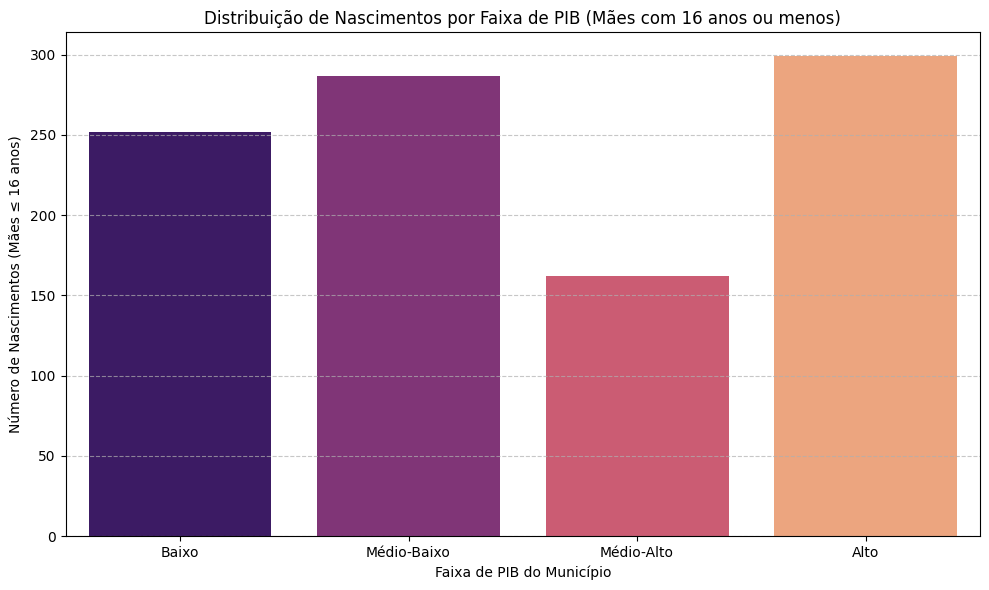

In [ ]:
# Filter the DataFrame for mothers 16 years old or younger
df_young_mothers = df_5_3_grouped[df_5_3_grouped['IDADEMAE'] <= 16].copy()

# Calculate the count of births in each PIB range for young mothers
pib_distribution_young_mothers = df_young_mothers['faixa_PIB'].value_counts().sort_index()

# Create a DataFrame for plotting
pib_distribution_young_mothers_df = pib_distribution_young_mothers.reset_index()
pib_distribution_young_mothers_df.columns = ['Faixa_PIB', 'Count_Births']

# Plotting the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Faixa_PIB', y='Count_Births', data=pib_distribution_young_mothers_df, palette='magma', hue='Faixa_PIB', legend=False)
plt.title('Distribuição de Nascimentos por Faixa de PIB (Mães com 16 anos ou menos)')
plt.xlabel('Faixa de PIB do Município')
plt.ylabel('Número de Nascimentos (Mães ≤ 16 anos)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
df_5_3_grouped.shape

(24081, 72)

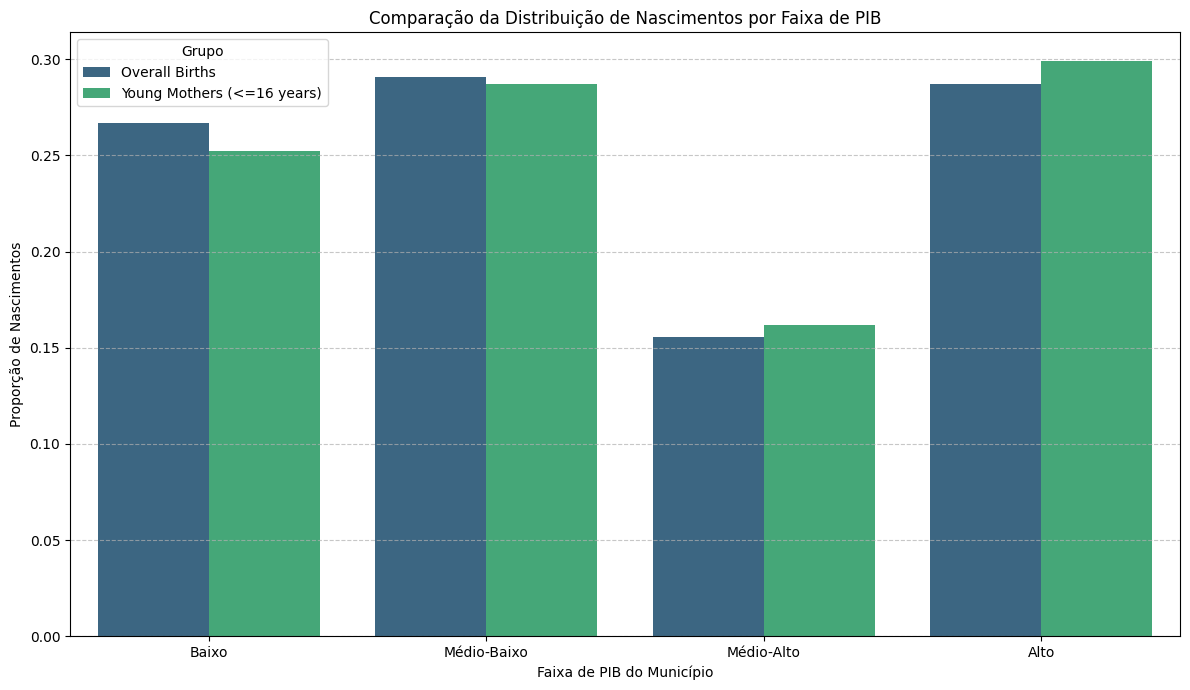

In [ ]:
# Calculate proportions for overall births
overall_pib_distribution = df_5_3_grouped['faixa_PIB'].value_counts().sort_index()
pib_distribution_df = overall_pib_distribution.reset_index()
pib_distribution_df.columns = ['Faixa_PIB', 'Count_Births']
pib_distribution_df['Proportion'] = pib_distribution_df['Count_Births'] / pib_distribution_df['Count_Births'].sum()
pib_distribution_df['Group'] = 'Overall Births'

# Calculate proportions for young mothers' births
pib_distribution_young_mothers_df['Proportion'] = pib_distribution_young_mothers_df['Count_Births'] / pib_distribution_young_mothers_df['Count_Births'].sum()
pib_distribution_young_mothers_df['Group'] = 'Young Mothers (<=16 years)'

# Combine the two DataFrames
comparison_df = pd.concat([pib_distribution_df, pib_distribution_young_mothers_df])

# Plotting the grouped bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Faixa_PIB', y='Proportion', hue='Group', data=comparison_df, palette='viridis')
plt.title('Comparação da Distribuição de Nascimentos por Faixa de PIB')
plt.xlabel('Faixa de PIB do Município')
plt.ylabel('Proporção de Nascimentos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Grupo')
plt.tight_layout()
plt.show()

### Comparação dos Nascimentos Totais e de Mães Jovens por Faixa de PIB (Contagens Absolutas)

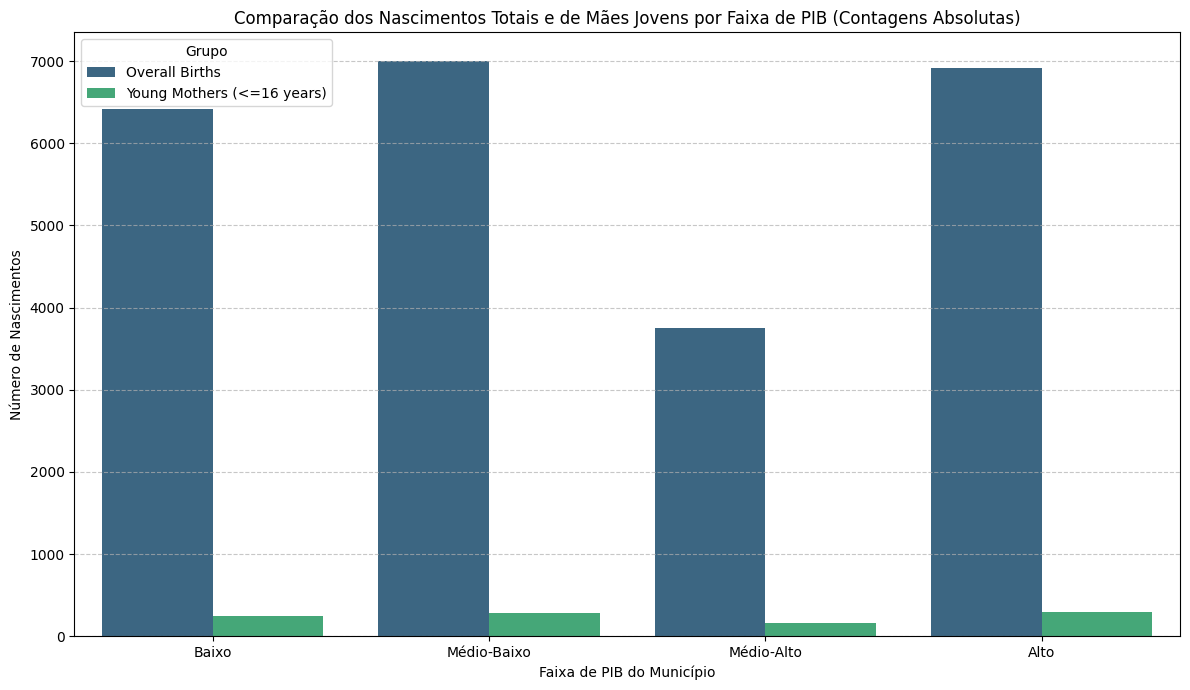

In [57]:
# Combine the two DataFrames containing absolute counts
comparison_counts_df = pd.concat([
    pib_distribution_df.drop(columns='Proportion'),
    pib_distribution_young_mothers_df.drop(columns='Proportion')
])

# Plotting the grouped bar chart for absolute counts
plt.figure(figsize=(12, 7))
sns.barplot(x='Faixa_PIB', y='Count_Births', hue='Group', data=comparison_counts_df, palette='viridis')
plt.title('Comparação dos Nascimentos Totais e de Mães Jovens por Faixa de PIB (Contagens Absolutas)')
plt.xlabel('Faixa de PIB do Município')
plt.ylabel('Número de Nascimentos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Grupo')
plt.tight_layout()
plt.show()

### Comparação da Distribuição de Nascimentos por Faixa de IDH

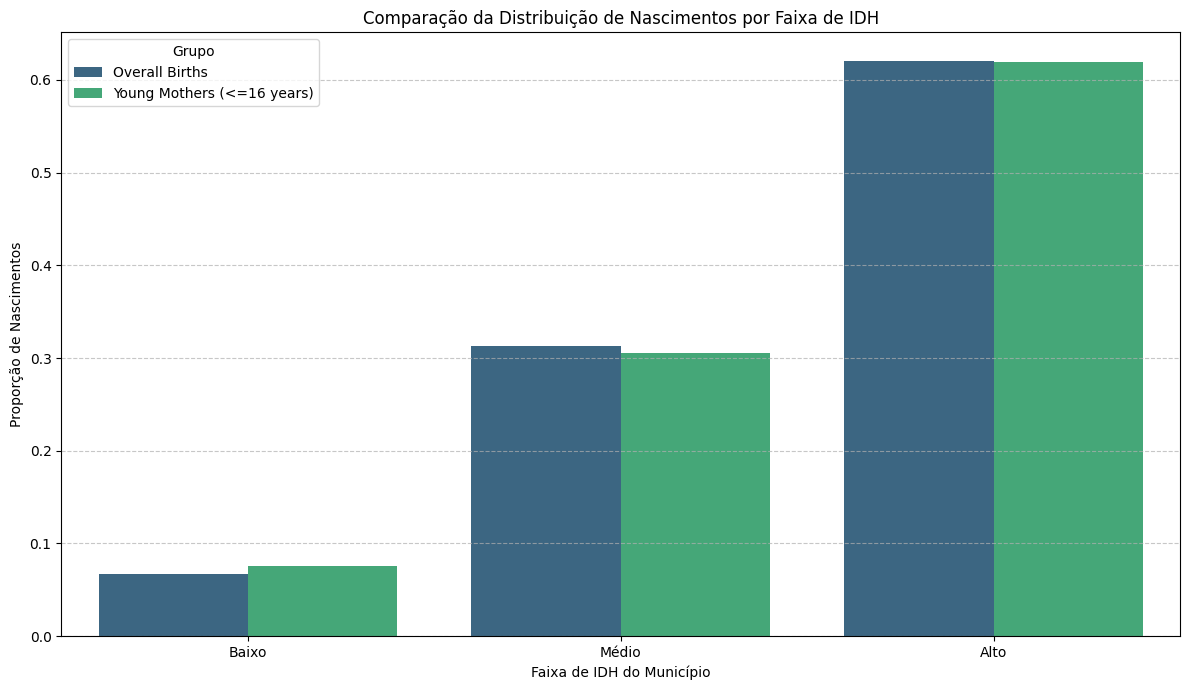

In [ ]:
# Calculate the count of overall births in each IDH range
overall_idh_distribution = df_5_grouped['faixa_IDH'].value_counts().sort_index()
overall_idh_distribution_df = overall_idh_distribution.reset_index()
overall_idh_distribution_df.columns = ['Faixa_IDH', 'Count_Births']
overall_idh_distribution_df['Proportion'] = overall_idh_distribution_df['Count_Births'] / overall_idh_distribution_df['Count_Births'].sum()
overall_idh_distribution_df['Group'] = 'Overall Births'

# Filter the DataFrame for mothers 16 years old or younger
df_young_mothers_idh = df_5_grouped[df_5_grouped['IDADEMAE'] <= 16].copy()

# Calculate the count of births in each IDH range for young mothers
idh_distribution_young_mothers = df_young_mothers_idh['faixa_IDH'].value_counts().sort_index()
idh_distribution_young_mothers_df = idh_distribution_young_mothers.reset_index()
idh_distribution_young_mothers_df.columns = ['Faixa_IDH', 'Count_Births']
idh_distribution_young_mothers_df['Proportion'] = idh_distribution_young_mothers_df['Count_Births'] / idh_distribution_young_mothers_df['Count_Births'].sum()
idh_distribution_young_mothers_df['Group'] = 'Young Mothers (<=16 years)'

# Combine the two DataFrames
comparison_idh_df = pd.concat([overall_idh_distribution_df, idh_distribution_young_mothers_df])

# Plotting the grouped bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Faixa_IDH', y='Proportion', hue='Group', data=comparison_idh_df, palette='viridis')
plt.title('Comparação da Distribuição de Nascimentos por Faixa de IDH')
plt.xlabel('Faixa de IDH do Município')
plt.ylabel('Proporção de Nascimentos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Grupo')
plt.tight_layout()
plt.show()

### Comparação da Distribuição de Nascimentos por Faixa de IFDM

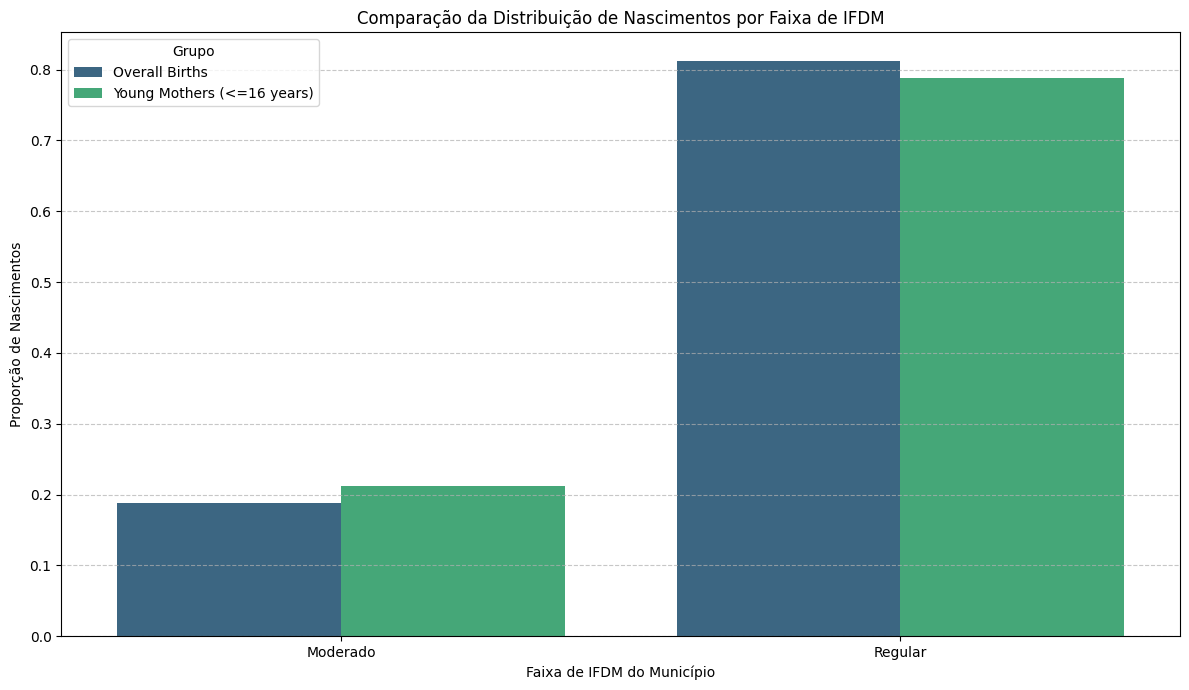

In [ ]:
# Calculate the count of overall births in each IFDM range
overall_ifdm_distribution = df_5_2['faixa_IFDM'].value_counts().sort_index()
overall_ifdm_distribution_df = overall_ifdm_distribution.reset_index()
overall_ifdm_distribution_df.columns = ['Faixa_IFDM', 'Count_Births']
overall_ifdm_distribution_df['Proportion'] = overall_ifdm_distribution_df['Count_Births'] / overall_ifdm_distribution_df['Count_Births'].sum()
overall_ifdm_distribution_df['Group'] = 'Overall Births'

# Filter the DataFrame for mothers 16 years old or younger
df_young_mothers_ifdm = df_5_2[df_5_2['IDADEMAE'] <= 16].copy()

# Calculate the count of births in each IFDM range for young mothers
ifdm_distribution_young_mothers = df_young_mothers_ifdm['faixa_IFDM'].value_counts().sort_index()
ifdm_distribution_young_mothers_df = ifdm_distribution_young_mothers.reset_index()
ifdm_distribution_young_mothers_df.columns = ['Faixa_IFDM', 'Count_Births']
ifdm_distribution_young_mothers_df['Proportion'] = ifdm_distribution_young_mothers_df['Count_Births'] / ifdm_distribution_young_mothers_df['Count_Births'].sum()
ifdm_distribution_young_mothers_df['Group'] = 'Young Mothers (<=16 years)'

# Combine the two DataFrames
comparison_ifdm_df = pd.concat([overall_ifdm_distribution_df, ifdm_distribution_young_mothers_df])

# Plotting the grouped bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Faixa_IFDM', y='Proportion', hue='Group', data=comparison_ifdm_df, palette='viridis')
plt.title('Comparação da Distribuição de Nascimentos por Faixa de IFDM')
plt.xlabel('Faixa de IFDM do Município')
plt.ylabel('Proporção de Nascimentos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Grupo')
plt.tight_layout()
plt.show()

### Analise as respostas encontradas, tire algum insight delas, conte pra gente algo encontrado nos dados.

Exemplo:
- Ah, descobri que a idade mediana das mulheres que deram a luz no ano de 2019 dos municipios com o PIB mais alto é a maior dentre todas.

- A distribuição dos municípios agrupados por IDH mostra que a maioria dos municípios do estado se encontram na faixa de IDH Alto. Apenas uma minoria está na faixa de IDH Baixo.

- Analisando os dados de gestação (qtde de gestações anteriores, se foi parto normal ou cesárea, filhos vivos, filhos mortos), não foi encontrada diferença relevante nas médias de cada agrupamento de IDH

- os dados de gestação também não encontram diferença significativa quando separadas por PIB.

- A média das quantidades de filhos mortos é consistentemente baixa em todas as faixas, independente do resultado do PIB.